### About the analysis below:

I analyzed a public e‑commerce A/B test where a company tested a new landing page against the old one. After cleaning the data to keep only valid assignments (control users on the old page, treatment users on the new page), I computed conversion rates as the mean of a 0/1 conversion flag. The control group converted at about 12.0% and the treatment group at about 11.9%, a small negative lift of roughly −0.16 percentage points. Using a two‑sample proportion z‑test, I obtained a p‑value of about 0.19, meaning that if there were truly no difference between pages, there is a 19% chance of observing a difference at least this large just due to random variation. Since this p‑value is much higher than the typical 5% threshold, I concluded there is no strong evidence that the new page improves conversion, and I would not recommend rolling it out as a clear upgrade based on this experiment alone.


##### Business Question 
Does the new landing page increase conversion compared to the old one?

In [2]:
import pandas as pd

df = pd.read_csv("ab_data.csv")
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [3]:
# Conversion rate by group
df.groupby("group")["converted"].mean()

# Conversion rate by landing page
df.groupby("landing_page")["converted"].mean()


landing_page
new_page    0.118841
old_page    0.120478
Name: converted, dtype: float64

In [4]:
#Cleaning the data
clean_df = df.query(
    "(group == 'control' and landing_page == 'old_page') or "
    "(group == 'treatment' and landing_page == 'new_page')"
)

clean_df.groupby("group")["converted"].mean()
len(df), len(clean_df)


(294478, 290585)

I first cleaned the dataset to keep only valid experiment rows, where control users saw the old page and treatment users saw the new page, so the groups match the intended design.

In [ ]:
#Calculating the conversion rates and lift
conv_rates = clean_df.groupby("group")["converted"].mean()
lift = conv_rates["treatment"] - conv_rates["control"]
conv_rates, lift


(group
 control      0.120386
 treatment    0.118807
 Name: converted, dtype: float64,
 np.float64(-0.0015790565976871451))

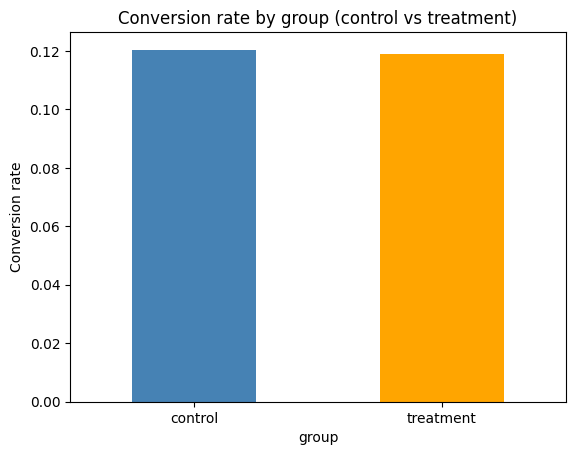

In [8]:
import matplotlib.pyplot as plt

conv_rates = clean_df.groupby("group")["converted"].mean()

conv_rates.plot(kind="bar", color=["steelblue", "orange"])
plt.ylabel("Conversion rate")
plt.title("Conversion rate by group (control vs treatment)")
plt.xticks(rotation=0)
plt.show()


The bar chart shows very similar conversion rates for control and treatment, consistent with the small, non‑significant difference in our statistical test.

In this experiment, about 12.0% of control users converted and about 11.9% of treatment users converted. The new page actually converts slightly less, with a difference of around −0.16 percentage points.

Next: If there were actually no real difference between pages, how likely is it to see a difference this big just by chance?

In [6]:
from statsmodels.stats.proportion import proportions_ztest

converted = clean_df.groupby("group")["converted"].sum()
total = clean_df.groupby("group")["converted"].count()

stat, pval = proportions_ztest(count=converted, nobs=total)
stat, pval


(np.float64(1.3116075339133115), np.float64(0.18965258971881804))

If there were actually no real difference between the old and new pages, there’s about a 19% chance we’d see a difference in conversion at least this large just from random noise.

Since 0.19 is much larger than 0.05:

  1.The difference (−0.16 percentage points) is not statistically significant at the 5% level.

  2.We do not have strong evidence that the new landing page is better or worse than the old one.

Control converts at about 12.0% and treatment at about 11.9%, so the new page is very slightly lower, but the difference is tiny. The p‑value is around 0.19, which means the result is consistent with random noise; we don’t have strong evidence that the new page changes conversion. Based on this test alone, I would not recommend rolling out the new page as an improvement.

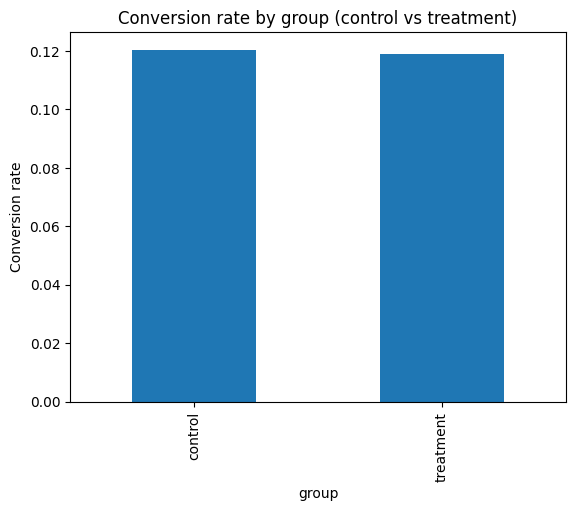

In [7]:
import matplotlib.pyplot as plt

conv_rates = clean_df.groupby("group")["converted"].mean()

conv_rates.plot(kind="bar")
plt.ylabel("Conversion rate")
plt.title("Conversion rate by group (control vs treatment)")
plt.show()


This chart shows very similar conversion rates for control and treatment, consistent with the small, non‑significant difference we found.

Because this was a randomized A/B test, assignment to control and treatment is designed to be random, which strongly reduces selection bias and makes the groups comparable on average. Under these conditions, the difference in conversion rates can be interpreted as a causal effect of the new page, subject to data quality assumptions. Since the estimated lift is very small and the p‑value (~0.19) is much larger than 0.05, we do not have strong evidence that the new page causally improves conversion, so I would not recommend rolling it out as a clear upgrade.